In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
metrics_df = pd.read_json("test_metrics.json")
metrics_df["engine"] = metrics_df['model'].apply(lambda x: "vLLM" if "nvidia/Llama-3.1-8B-Instruct-NVFP4" in x else "Ollama")
metrics_df["concurrency"] = metrics_df["concurrency"].astype(int)
# metrics_df["requests_per_sec"] = metrics_df["requests_per_sec"].astype(int)
metrics_df["model"] = metrics_df["model"].replace("meta-llama/Llama-3.1-8B", "Meta LLaMA 3.1 8B").replace("nvidia/Llama-3.1-8B-Instruct-NVFP4", "NVIDIA LLaMA 3.1 8B")
metrics_df.head()

,timestamp,backend,model,url,dataset_split,requests,concurrency,requests_per_sec,tokens_per_sec,avg_latency_s,p50_latency_s,p95_latency_s,wall_time_s,engine
0,2026-05-09 11:28:53.711400747,vllm,NVIDIA LLaMA 3.1 8B,http://localhost:8000/v1/chat/completions,test_sft,1024,1,0.470936,173.621360,2.123377,2.348461,2.472014,2174.392593,vLLM
1,2026-05-09 11:48:55.275974989,vllm,NVIDIA LLaMA 3.1 8B,http://localhost:8000/v1/chat/completions,test_sft,1024,2,0.921262,338.983213,2.170231,2.386952,2.570673,1111.518170,vLLM
2,2026-05-09 11:59:50.985449076,vllm,NVIDIA LLaMA 3.1 8B,http://localhost:8000/v1/chat/completions,test_sft,1024,4,1.760537,648.539586,2.267460,2.470864,2.729842,581.640671,vLLM
3,2026-05-09 12:06:22.775961399,vllm,NVIDIA LLaMA 3.1 8B,http://localhost:8000/v1/chat/completions,test_sft,1024,8,3.256963,1199.099979,2.446920,2.652722,3.040690,314.403308,vLLM
4,2026-05-09 12:10:48.404856205,vllm,NVIDIA LLaMA 3.1 8B,http://localhost:8000/v1/chat/completions,test_sft,1024,16,5.578836,2054.918339,2.848370,3.065228,3.611848,183.550846,vLLM


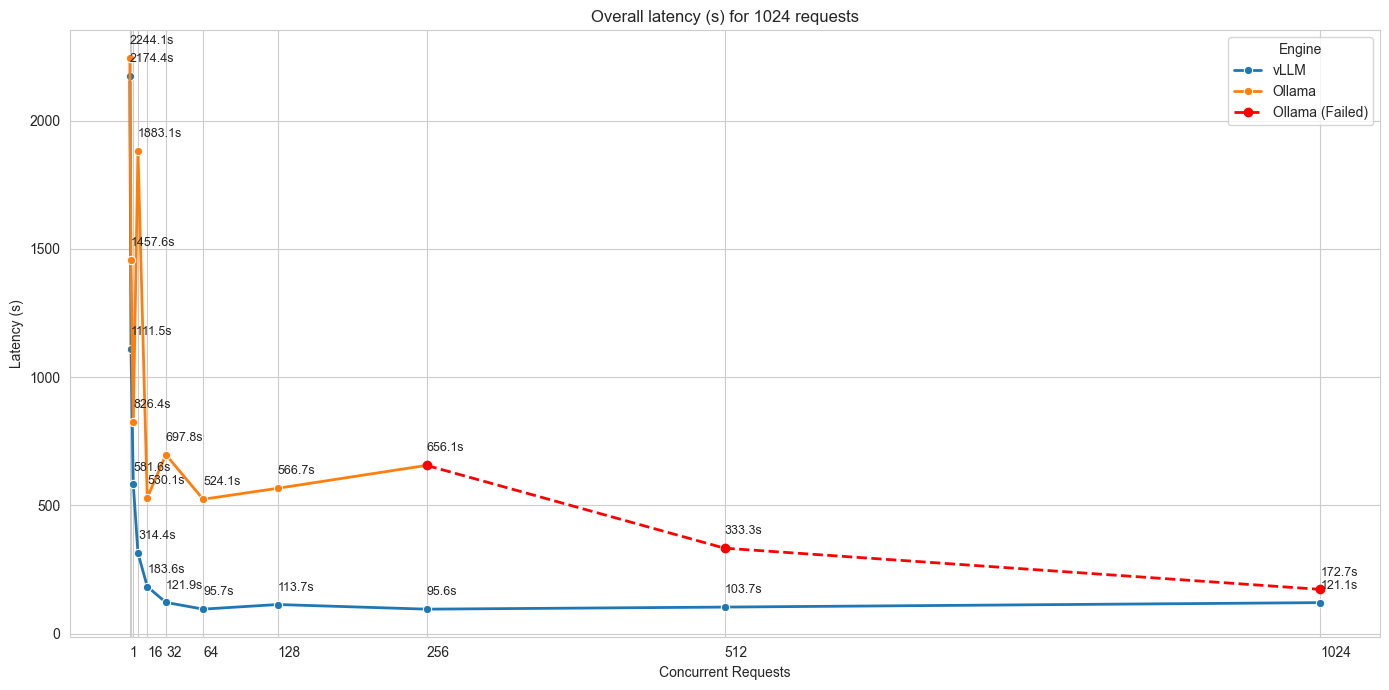

In [3]:
fig, ax = plt.subplots(figsize=(14, 7))

# Split data into normal and failed portions for Ollama
normal_data = metrics_df[~((metrics_df["engine"] == "Ollama") & (metrics_df["concurrency"] > 256))].sort_values("concurrency")
failed_data = metrics_df[(metrics_df["engine"] == "Ollama") & (metrics_df["concurrency"] >= 256)].sort_values("concurrency")

# Plot normal data
sns.lineplot(
    data=normal_data,
    x="concurrency",
    y="wall_time_s",
    hue="engine",
    marker="o",
    linewidth=2,
    ax=ax
)

# Plot failed Ollama data with dashed red line
if not failed_data.empty:
    ax.plot(
        failed_data["concurrency"],
        failed_data["wall_time_s"],
        marker="o",
        linewidth=2,
        linestyle="--",
        color="red",
        label="Ollama (Failed)",
        markersize=6
    )

plt.title("Overall latency (s) for 1024 requests")
plt.xlabel("Concurrent Requests")
plt.ylabel("Latency (s)")

# Set x-axis to show all concurrency levels
concurrency_levels = sorted(metrics_df["concurrency"].unique())
ax.set_xticks(concurrency_levels)
ax.set_xticklabels(
    [str(int(c)) if c not in [2,4, 8] else "" for c in concurrency_levels], rotation=0, ha='left'
)

for conc_req, latency in zip(metrics_df["concurrency"], metrics_df["wall_time_s"]):
    ax.annotate(f"{latency:.1f}s", (conc_req, latency), textcoords="offset points", xytext=(0,10), ha='left', fontsize=9)

plt.legend(title="Engine")
plt.tight_layout()
plt.show()  

In [ ]:
import matplotlib.patches as mpatches

# Data split
mask_failed = (metrics_df["engine"] == "Ollama") & (metrics_df["concurrency"] >= 256)
normal_data = metrics_df[~mask_failed].sort_values("concurrency")
failed_data = metrics_df[mask_failed].sort_values("concurrency")

# Style
PALETTE   = {"vLLM": "#4C72B0", "Ollama": "orange"}
FAIL_CLR  = "#C44E52"
FONT      = {"fontsize": 9, "fontfamily": "monospace"}

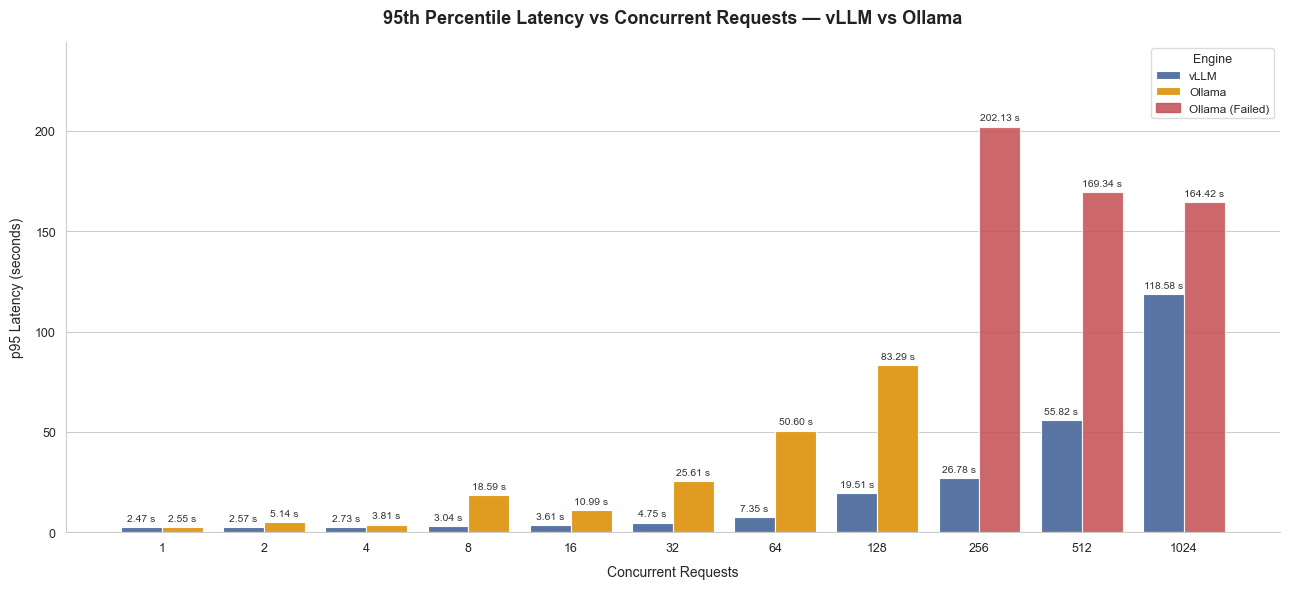

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_facecolor("white")

# Main grouped barplot
sns.barplot(
    data=normal_data,
    x="concurrency",
    y="p95_latency_s",
    hue="engine",
    palette=PALETTE,
    edgecolor="white",
    linewidth=0.8,
    ax=ax,
)

bar_patches = [p for p in ax.patches if p.get_width() > 0]

# Map concurrency values to their x-axis tick index
xtick_vals  = sorted(metrics_df["concurrency"].unique())
tick_index  = {v: i for i, v in enumerate(xtick_vals)}
n_engines   = normal_data["engine"].nunique()
bar_width   = bar_patches[0].get_width() if bar_patches else 0.4

# Overlay failed Ollama bars at the correct grouped position
if not failed_data.empty:
    engines_in_plot = normal_data["engine"].unique().tolist()
    ollama_offset   = (
        engines_in_plot.index("Ollama") - (n_engines - 1) / 2
    ) * bar_width if "Ollama" in engines_in_plot else 0

    fail_x, fail_y = [], []
    for _, row in failed_data.iterrows():
        xc = tick_index[row["concurrency"]] + ollama_offset
        yv = row["p95_latency_s"]
        fail_x.append(xc)
        fail_y.append(yv)

        ax.bar(xc, yv, width=bar_width, color=FAIL_CLR,
               alpha=0.85, edgecolor="white", linewidth=0.8, zorder=3)

# Bar labels on normal bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f s", padding=3,
                 fontsize=7.5, color="#333333")

# Grid & spines
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Legend (add failed entry manually)
handles, labels = ax.get_legend_handles_labels()
handles.append(mpatches.Patch(color=FAIL_CLR, alpha=0.85, label="Ollama (Failed)"))
ax.legend(handles=handles, title="Engine", title_fontsize=9,
          fontsize=8.5, framealpha=0.7, edgecolor="#CCCCCC")

# Labels & title
ax.set_title(
    "95th Percentile Latency vs Concurrent Requests - vLLM vs Ollama",
    fontsize=13, fontweight="bold", pad=14, color="#222222"
)
ax.set_xlabel("Concurrent Requests", fontsize=10, labelpad=8)
ax.set_ylabel("p95 Latency (seconds)",  fontsize=10, labelpad=8)
ax.tick_params(axis="both", labelsize=9)

# Give headroom for bar labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

In [ ]:
mask_failed = (metrics_df["engine"] == "Ollama") & (metrics_df["concurrency"] >= 256)
normal_data = metrics_df[~mask_failed].sort_values("concurrency")
failed_data = metrics_df[mask_failed].sort_values("concurrency")

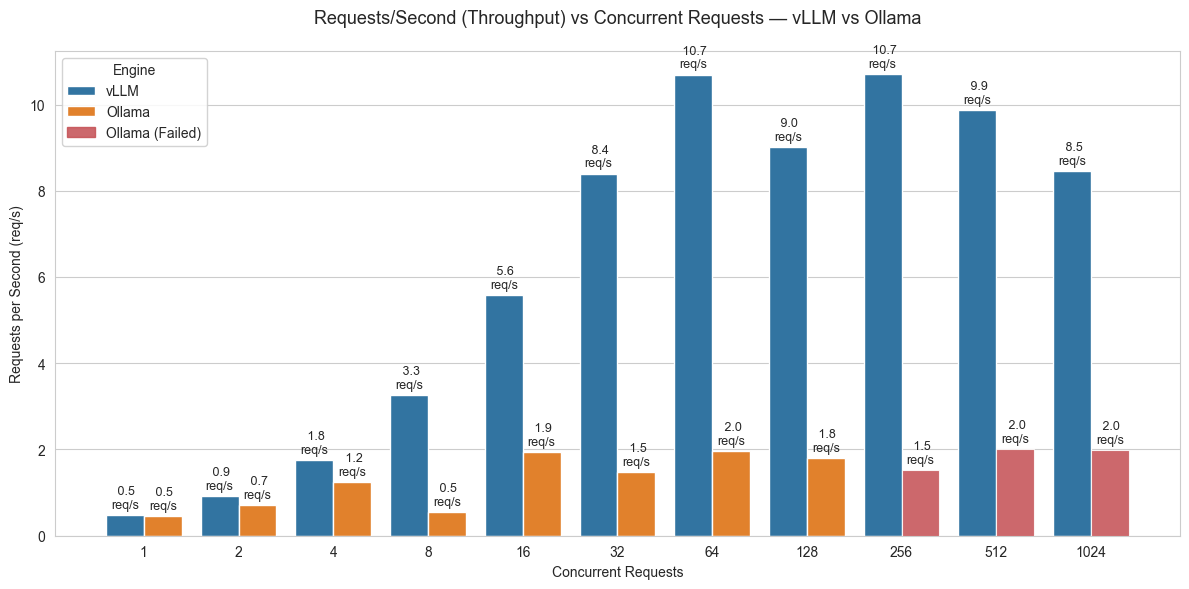

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=normal_data,
    x="concurrency",
    y="requests_per_sec",
    hue="engine",
    ax=ax
)

bar_patches = [p for p in ax.patches if p.get_width() > 0]
xtick_vals = sorted(metrics_df["concurrency"].unique())
tick_index = {v: i for i, v in enumerate(xtick_vals)}
n_engines = normal_data["engine"].nunique()
bar_width = bar_patches[0].get_width() if bar_patches else 0.4

if not failed_data.empty:
    engines_in_plot = normal_data["engine"].unique().tolist()
    ollama_offset = (
        engines_in_plot.index("Ollama") - (n_engines - 1) / 2
    ) * bar_width if "Ollama" in engines_in_plot else 0

    for _, row in failed_data.iterrows():
        xc = tick_index[row["concurrency"]] + ollama_offset
        yv = row["requests_per_sec"]
        ax.bar(
            xc,
            yv,
            width=bar_width,
            color="#C44E52",
            alpha=0.85,
            edgecolor="white",
            linewidth=0.8,
            zorder=3,
        )

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=" %.1f\nreq/s",
        padding=3,
        fontsize=9
    )

handles, labels = ax.get_legend_handles_labels()
handles.append(mpatches.Patch(color="#C44E52", alpha=0.85, label="Ollama (Failed)"))
ax.legend(handles=handles, title="Engine", framealpha=0.85)

plt.title("Requests/Second (Throughput) vs Concurrent Requests - vLLM vs Ollama", fontsize=13, pad=20)
plt.xlabel("Concurrent Requests")
plt.ylabel("Requests per Second (req/s)")

plt.tight_layout()
plt.show()

In [ ]:
mask_failed = (metrics_df["engine"] == "Ollama") & (metrics_df["concurrency"] >= 256)
normal_data = metrics_df[~mask_failed].sort_values("concurrency")
failed_data = metrics_df[mask_failed].sort_values("concurrency")

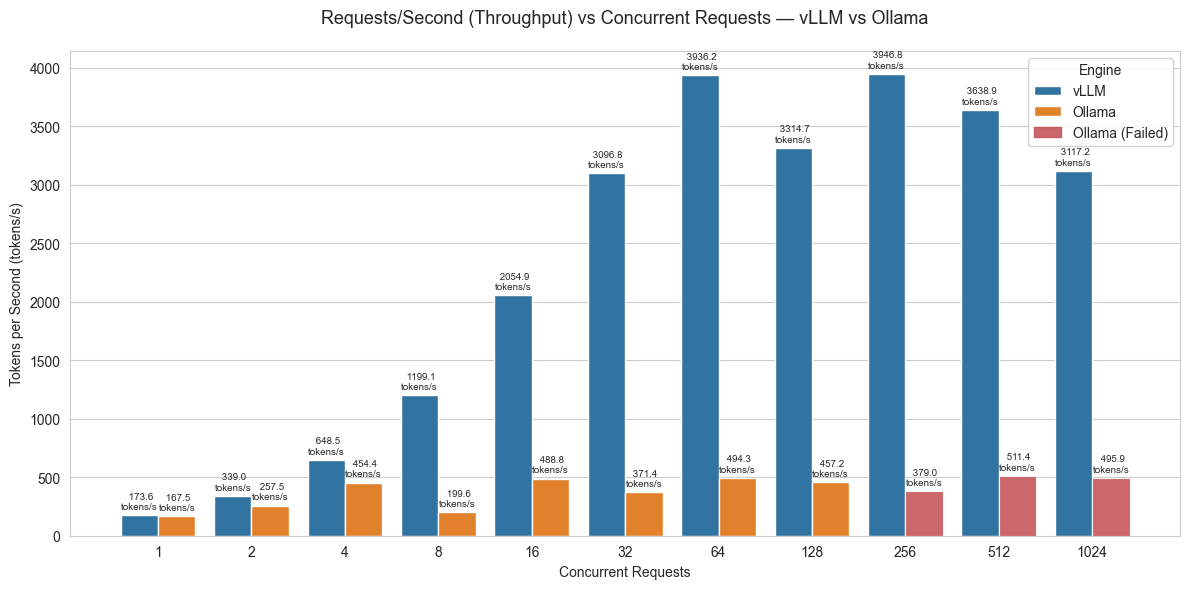

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=normal_data,
    x="concurrency",
    y="tokens_per_sec",
    hue="engine",
    ax=ax
)

bar_patches = [p for p in ax.patches if p.get_width() > 0]
xtick_vals = sorted(metrics_df["concurrency"].unique())
tick_index = {v: i for i, v in enumerate(xtick_vals)}
n_engines = normal_data["engine"].nunique()
bar_width = bar_patches[0].get_width() if bar_patches else 0.4

if not failed_data.empty:
    engines_in_plot = normal_data["engine"].unique().tolist()
    ollama_offset = (
        engines_in_plot.index("Ollama") - (n_engines - 1) / 2
    ) * bar_width if "Ollama" in engines_in_plot else 0

    for _, row in failed_data.iterrows():
        xc = tick_index[row["concurrency"]] + ollama_offset
        yv = row["tokens_per_sec"]
        ax.bar(
            xc,
            yv,
            width=bar_width,
            color="#C44E52",
            alpha=0.85,
            edgecolor="white",
            linewidth=0.8,
            zorder=3,
        )

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=" %.1f\ntokens/s",
        padding=3,
        fontsize=7
    )

handles, labels = ax.get_legend_handles_labels()
handles.append(mpatches.Patch(color="#C44E52", alpha=0.85, label="Ollama (Failed)"))
ax.legend(handles=handles, title="Engine", framealpha=0.85)

plt.title("Requests/Second (Throughput) vs Concurrent Requests - vLLM vs Ollama", fontsize=13, pad=20)
plt.xlabel("Concurrent Requests")
plt.ylabel("Tokens per Second (tokens/s)")

plt.tight_layout()
plt.show()